# Visualizing Self-Adjoint Operators

A self-adjoint operator (real case: symmetric matrix, complex case: Hermitian matrix) satisfies

$$
A = A^*.
$$

Key geometric facts we will visualize:

1. Real eigenvalues
2. Orthogonal eigenvectors (for distinct eigenvalues)
3. Action as scaling along orthogonal eigendirections
4. Level sets of $x^\top A x$ aligned with eigenvectors

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 2x2 symmetric matrix (self-adjoint in R^2)
A = np.array([[3.0, 1.2],
              [1.2, 1.0]])

eigvals, eigvecs = np.linalg.eigh(A)  # eigh for symmetric/Hermitian

print('A =\n', A)
print('Eigenvalues =', eigvals)
print('Orthogonality check v1·v2 =', float(eigvecs[:, 0] @ eigvecs[:, 1]))
print('Symmetry check ||A - A^T|| =', np.linalg.norm(A - A.T))

A =
 [[3.  1.2]
 [1.2 1. ]]
Eigenvalues = [0.43795006 3.56204994]
Orthogonality check v1·v2 = 0.0
Symmetry check ||A - A^T|| = 0.0


## 1) Geometry: unit circle under a self-adjoint map

Applying $A$ to the unit circle gives an ellipse. Its principal axes align with the eigenvectors of $A$.

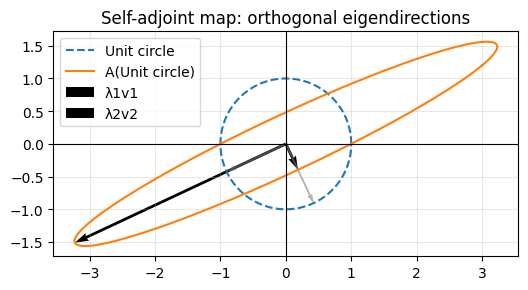

In [3]:
theta = np.linspace(0, 2 * np.pi, 400)
circle = np.vstack((np.cos(theta), np.sin(theta)))
ellipse = A @ circle

plt.figure(figsize=(6, 6))
plt.plot(circle[0], circle[1], '--', label='Unit circle')
plt.plot(ellipse[0], ellipse[1], label='A(Unit circle)')

origin = np.zeros(2)
for i in range(2):
    v = eigvecs[:, i]
    lam = eigvals[i]
    plt.quiver(*origin, *(v * lam), angles='xy', scale_units='xy', scale=1,
               width=0.006, label=f'λ{i+1}v{i+1}')
    plt.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1,
               width=0.004, alpha=0.6, color='gray')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Self-adjoint map: orthogonal eigendirections')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2) Quadratic form contours $x^\top A x$

For symmetric $A$, level sets of $x^\top A x$ are aligned with eigenvectors. This gives a direct geometric view of the spectral basis.

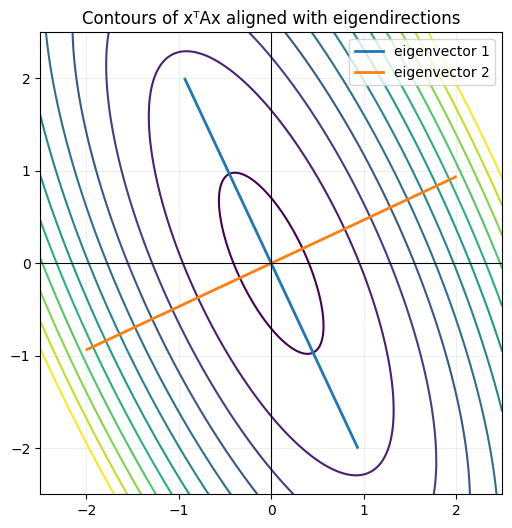

In [4]:
grid = np.linspace(-2.5, 2.5, 300)
X, Y = np.meshgrid(grid, grid)
Z = A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2

plt.figure(figsize=(6, 6))
levels = np.linspace(np.percentile(Z, 5), np.percentile(Z, 95), 12)
plt.contour(X, Y, Z, levels=levels)

for i in range(2):
    v = eigvecs[:, i]
    plt.plot([-2.2 * v[0], 2.2 * v[0]], [-2.2 * v[1], 2.2 * v[1]],
             linewidth=2, label=f'eigenvector {i+1}')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Contours of xᵀAx aligned with eigendirections')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 3) Complex Hermitian example: real spectrum

Hermitian matrices ($H=H^*$) are self-adjoint over $\mathbb{C}^n$. Their eigenvalues are always real.

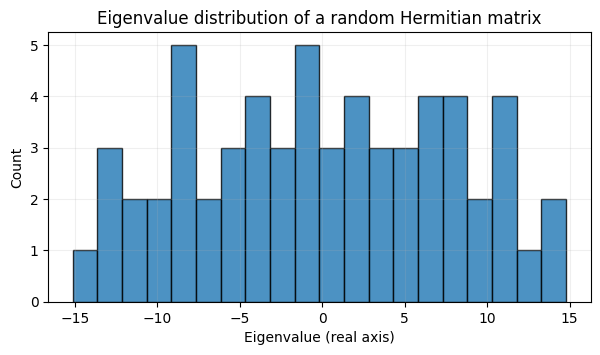

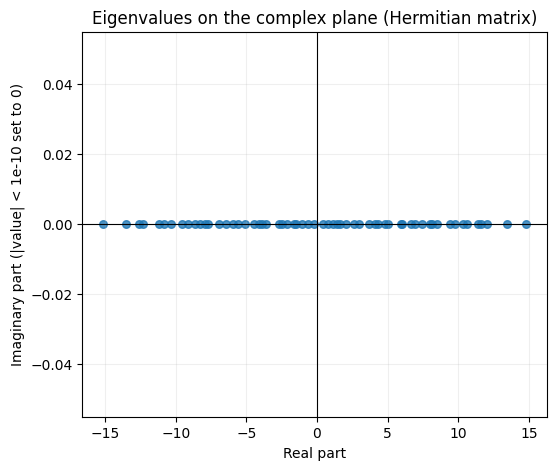

Max imaginary part after thresholding = 0.0


In [6]:
n = 60
M = np.random.randn(n, n) + 1j * np.random.randn(n, n)
H = 0.5 * (M + M.conj().T)

evals = np.linalg.eigvalsh(H)
evals_general = np.linalg.eigvals(H)

# Zero-out tiny numerical values for cleaner display
tol = 1e-10
real_parts = np.real(evals_general)
imag_parts = np.imag(evals_general)
real_parts[np.abs(real_parts) < tol] = 0.0
imag_parts[np.abs(imag_parts) < tol] = 0.0
imag_leak = np.max(np.abs(imag_parts))

plt.figure(figsize=(7, 3.5))
plt.hist(evals, bins=20, edgecolor='black', alpha=0.8)
plt.title('Eigenvalue distribution of a random Hermitian matrix')
plt.xlabel('Eigenvalue (real axis)')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.show()

# Plot eigenvalues on the complex plane
plt.figure(figsize=(6, 5))
plt.scatter(real_parts, imag_parts, s=30, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Eigenvalues on the complex plane (Hermitian matrix)')
plt.xlabel('Real part')
plt.ylabel('Imaginary part (|value| < 1e-10 set to 0)')
plt.grid(alpha=0.2)
plt.show()

print('Max imaginary part after thresholding =', float(imag_leak))

Let
$$
L=\frac{d^2}{dx^2}
$$
on the interval $[a,b]$, with inner product
$$
\langle u,v\rangle=\int_a^b u(x)\,\overline{v(x)}\,dx.
$$

First compute
$$
\langle Lu,v\rangle=\int_a^b u''\,\overline{v}\,dx
=\left[u'\overline{v}\right]_a^b-\int_a^b u'\,\overline{v'}\,dx.
$$

Next compute
$$
\langle u,Lv\rangle=\int_a^b u\,\overline{v''}\,dx
=\left[u\overline{v'}\right]_a^b-\int_a^b u'\,\overline{v'}\,dx.
$$

Subtracting gives
$$
\langle Lu,v\rangle-\langle u,Lv\rangle
=\left[u'\overline{v}-u\overline{v'}\right]_a^b.
$$

Therefore, for symmetry we require
$$
\left[u'\overline{v}-u\overline{v'}\right]_a^b=0
\quad\text{for all }u,v\text{ in the domain.}
$$

This boundary term is exactly where boundary conditions come from.
Typical choices are Dirichlet ($u(a)=u(b)=0$), Neumann ($u'(a)=u'(b)=0$), Robin, or periodic conditions.

For the operator
$$
L=\frac{d^2}{dx^2}
$$
on the interval
$$
[a,b],
$$
integration by parts gives the boundary term
$$
\left[u'\overline{v}-u\overline{v'}\right]_a^b
=
\left(u'(b)\overline{v(b)}-u(b)\overline{v'(b)}\right)
-
\left(u'(a)\overline{v(a)}-u(a)\overline{v'(a)}\right).
$$

With periodic boundary conditions
$$
u(a)=u(b),\quad u'(a)=u'(b),\quad
v(a)=v(b),\quad v'(a)=v'(b),
$$
we get
$$
u'(b)\overline{v(b)}-u(b)\overline{v'(b)}
=
u'(a)\overline{v(a)}-u(a)\overline{v'(a)}.
$$

Hence
$$
\left[u'\overline{v}-u\overline{v'}\right]_a^b=0.
$$
So the boundary contribution vanishes.

Under Dirichlet boundary conditions, the sine family is the eigenfunction basis.

For the Sturm–Liouville problem on \([a,b]\):
$$
-u''=\lambda u,\qquad u(a)=u(b)=0,
$$
the eigenvalues and eigenfunctions are
$$
\lambda_n=\left(\frac{n\pi}{b-a}\right)^2,\qquad
\phi_n(x)=\sin\!\left(\frac{n\pi(x-a)}{b-a}\right),\quad n=1,2,\dots
$$

So “$\sin(kx)$” is correct in spirit, with the shift/scale adjusted to the interval \([a,b]\).

Any sufficiently nice function \(f\) on \([a,b]\) can be represented (in the \(L^2\) sense) as
$$
f(x)\sim \sum_{n=1}^{\infty} c_n\,\phi_n(x),
$$
with coefficients
$$
c_n=\frac{\langle f,\phi_n\rangle}{\langle \phi_n,\phi_n\rangle}.
$$

This is exactly the Fourier sine series expansion.  
So yes: functions are represented as linear combinations (infinite series) of the Dirichlet eigenfunctions.

### \(L^2\) and Sobolev-space notation

- **Square-integrable space**
$$
L^2(a,b)=\left\{f:\int_a^b |f(x)|^2\,dx<\infty\right\}.
$$

- **First-order Sobolev space**
$$
H^1(a,b)=\{u:\ u,\ u'\in L^2(a,b)\},
$$
where \(u'\) is the weak derivative.

- **Second-order Sobolev space**
$$
H^2(a,b)=\{u:\ u,\ u',\ u''\in L^2(a,b)\}.
$$

- **Zero-trace subspace (Dirichlet type)**
$$
H_0^1(a,b)=\{u\in H^1(a,b):u(a)=u(b)=0\ \text{(trace sense)}\}.
$$

---

### Eigenfunctions and Sobolev spaces

For
$$
-u''=\lambda u \quad \text{on }(a,b),
$$
the **ambient Hilbert space** is usually \(L^2(a,b)\), but the operator acts on a **domain** with extra regularity and boundary conditions, e.g.
$$
D(A)=H^2(a,b)\cap H_0^1(a,b)
$$
for Dirichlet BC.

An eigenfunction \(\phi\) satisfies
$$
A\phi=\lambda\phi,\qquad \phi\in D(A).
$$

So eigenfunctions are not just in \(L^2\); they must also lie in the Sobolev domain that encodes derivatives and boundary conditions.  
For Dirichlet BC, the eigenfunctions are
$$
\phi_n(x)=\sin\!\left(\frac{n\pi(x-a)}{b-a}\right),\quad n=1,2,\dots
$$
which belong to \(H^2(a,b)\cap H_0^1(a,b)\).

Yes. \(A\) is the **actual linear operator** (the differential expression together with boundary conditions encoded in its domain).

For the example discussed:
$$
A u = -u''.
$$

With Dirichlet boundary conditions, define
$$
D(A)=H^2(a,b)\cap H_0^1(a,b),
$$
so
$$
A: D(A)\subset L^2(a,b)\to L^2(a,b),\qquad Au=-u''.
$$

An eigenfunction $\phi$ satisfies
$$
A\phi=\lambda\phi,\quad \phi\in D(A).
$$

So 
$$
L=-\dfrac{d^2}{dx^2}
$$

is often the **formal differential expression**, while \(A\) is the **operator realization** on a specific domain.

Note that the orthogonality is a consequence of the self-adjoint + BCs


An eigenfunction is defined by
$$
A\phi=\lambda\phi,\qquad \phi\neq 0.
$$

There is **no orthogonality requirement** in this definition.

Orthogonality appears as an additional property when \(A\) is self-adjoint (with appropriate boundary conditions). If
$$
A\phi_m=\lambda_m\phi_m,\qquad A\phi_n=\lambda_n\phi_n,\qquad \lambda_m\neq\lambda_n,
$$
then
$$
\langle \phi_m,\phi_n\rangle=0.
$$

So:

- **Linearity of \(A\)** is part of the operator setup.
- **Eigenfunction condition** is $A\phi=\lambda\phi$.
- **Orthogonality** is a consequence of self-adjointness (for distinct eigenvalues), not part of the base definition.

Orthogonality itself is **not** defined by the operator. It is defined by the inner product:
$$
\langle f,g\rangle=0.
$$

For a self-adjoint operator \(A\),
$$
\langle Au,v\rangle=\langle u,Av\rangle.
$$

Take eigenfunctions $\phi_m,\phi_n$:
$$
A\phi_m=\lambda_m\phi_m,\qquad A\phi_n=\lambda_n\phi_n.
$$

Then
$$
\langle A\phi_m,\phi_n\rangle=\lambda_m\langle \phi_m,\phi_n\rangle,
$$
and also
$$
\langle A\phi_m,\phi_n\rangle=\langle \phi_m,A\phi_n\rangle
=\lambda_n\langle \phi_m,\phi_n\rangle.
$$

So
$$
(\lambda_m-\lambda_n)\langle \phi_m,\phi_n\rangle=0.
$$

If $\lambda_m\neq\lambda_n$, it follows that
$$
\langle \phi_m,\phi_n\rangle=0.
$$

Not for **all operators** the dot product is true

$$
\langle \phi_m,\phi_n\rangle=0
$$
is true when the chosen functions are orthogonal under the given inner product/domain (and often weight), typically because they are eigenfunctions of a **self-adjoint** operator.

Examples in $L^2$:

- On $[-\pi,\pi]$:
$$
\langle \sin(mx),\sin(nx)\rangle=0,\quad
\langle \cos(mx),\cos(nx)\rangle=0\quad (m\neq n).
$$

- Complex exponentials on $[0,2\pi]$:
$$
\phi_n(x)=e^{inx},\qquad
\langle \phi_m,\phi_n\rangle=\int_0^{2\pi} e^{i(m-n)x}\,dx=0\quad (m\neq n).
$$

But for a general (non-self-adjoint) operator, distinct eigenfunctions need **not** be orthogonal. So orthogonality is not automatic “for all operators”; it depends on operator class, boundary conditions, and inner product.

Not in the standard case.

For the usual function-space inner product,
$$
\langle u,v\rangle_{L^2}=\int_a^b u(x)\,\overline{v(x)}\,dx,
$$
there is **no differential operator** in the definition.

What is “baked in” is usually one of these:

1. **The operator domain** \(D(A)\): functions must have enough derivatives and satisfy boundary conditions.
2. A different inner product (Sobolev/energy), e.g.
$$
\langle u,v\rangle_{H^1}=\int_a^b u\overline v\,dx+\int_a^b u'\overline{v'}\,dx,
$$
which does include derivatives.
3. The **bilinear form** associated with an operator, e.g.
$$
a(u,v)=\int_a^b u'(x)\overline{v'(x)}\,dx,
$$
for $A=-\dfrac{d^2}{dx^2}$ with suitable BCs.

So: in $L^2$, no; in Sobolev/energy settings, yes.

Close—almost.

For Dirichlet conditions
$$
u(a)=u(b)=0,\quad u(x)=\sin(k(x-a)),
$$
you need
$$
\sin(k(b-a))=0
\;\Longrightarrow\;
k(b-a)=n\pi,\quad n\in\mathbb{Z}.
$$

So the interval length must be an **integer multiple of $\pi/k$** (half-period units), not necessarily a full period $2\pi/k$.

- \(n=1\): half-period  
- \(n=2\): full period  
- \(n=3\): \(1.5\) periods, etc.

So “full period” is sufficient, but not necessary.

Not exactly.

- For the **first-derivative operator** 
$$
D=\frac{d}{dx},
$$
the eigenfunctions are complex exponentials:
$$
D\,e^{ikx}=ik\,e^{ikx}.
$$
So $e^{ikx}$ are true eigenfunctions.

- $\sin(kx)$ and $\cos(kx)$ are **not** eigenfunctions of \(D\), because
$$
\frac{d}{dx}\sin(kx)=k\cos(kx),\qquad
\frac{d}{dx}\cos(kx)=-k\sin(kx),
$$
so differentiation mixes them.

- For the **second derivative / 1D Laplacian**
$$
\frac{d^2}{dx^2}
\quad\text{(or }-\frac{d^2}{dx^2}\text{)},
$$
both exponentials and sine/cosine are eigenfunctions (with boundary-condition-dependent basis):
$$
\frac{d^2}{dx^2}e^{ikx}=-k^2 e^{ikx},\quad
\frac{d^2}{dx^2}\sin(kx)=-k^2\sin(kx),\quad
\frac{d^2}{dx^2}\cos(kx)=-k^2\cos(kx).
$$

So: **exp** is the natural eigenbasis for $d/dx$ (periodic setting), while **sin/cos and exp** are all eigenfunctions of the Laplacian in 1D, depending on boundary conditions.

**Robin boundary conditions** are mixed boundary conditions that combine value and normal derivative at the boundary.

For a 1D interval \([a,b]\), they are typically written as
$$
\alpha_a\,u(a)+\beta_a\,u'(a)=g_a,\qquad
\alpha_b\,u(b)+\beta_b\,u'(b)=g_b.
$$

- If \(g_a=g_b=0\): **homogeneous Robin**.
- If not: **non-homogeneous Robin**.

They interpolate between:

- **Dirichlet** (\(\beta=0\)): prescribe \(u\).
- **Neumann** (\(\alpha=0\)): prescribe \(u'\).

So Robin is a weighted blend of both.

In PDE form (higher dimensions), on boundary \(\partial\Omega\):
$$
\alpha\,u+\beta\,\frac{\partial u}{\partial n}=g,
$$
where \(\frac{\partial u}{\partial n}\) is the outward normal derivative.

Common physical meaning (heat transfer):
$$
-k\,\frac{\partial T}{\partial n}=h\,(T-T_\infty),
$$
which is a Robin condition modeling convection at the boundary.

The **Sturm–Liouville problem** is a general eigenvalue problem for a second-order linear differential operator of the form:
$$
\frac{d}{dx}\left[p(x)\frac{du}{dx}\right]-q(x)u+\lambda w(x)u=0,\quad x\in[a,b],
$$
with boundary conditions at \(a\) and \(b\).

Here:

- $p(x)>0$: coefficient function (often related to geometry/medium).
- $q(x)$: potential term.
- $w(x)>0$: **weight function** (also called density).
- $\lambda$: eigenvalue to be found.

The operator is often written as
$$
L u = -\frac{d}{dx}\left[p(x)\frac{du}{dx}\right]+q(x)u,
$$
so the problem becomes
$$
Lu=\lambda w(x)u.
$$

The inner product is **weighted**:
$$
\langle u,v\rangle_w=\int_a^b u(x)\overline{v(x)}\,w(x)\,dx.
$$

Key results when \(p,q,w\) are nice and BCs are self-adjoint:

- Eigenvalues $\lambda_n$ are **real**.
- Eigenfunctions $\phi_n$ are **orthogonal** under the weighted inner product:
$$
\langle \phi_m,\phi_n\rangle_w=0,\quad m\neq n.
$$
- Eigenfunctions are **complete**: any suitable \(f\) can be expanded as
$$
f(x)=\sum_{n=1}^\infty c_n\phi_n(x),\quad c_n=\frac{\langle f,\phi_n\rangle_w}{\langle \phi_n,\phi_n\rangle_w}.
$$

Special cases:

- \(p=1,\,q=0,\,w=1\): gives \(-u''=$\lambda$ u\), the plain Fourier/sine/cosine problem.
- \(p=1-x^2,\,q=0,\,w=1\): gives **Legendre** polynomials.
- \(p=x,\,q=0,\,w=x\): gives **Bessel** functions.

## Boundary conditions and self-adjointness (KaTeX)

For the momentum operator
$$
A=-i\frac{d}{dx}
$$
on an interval $[a,b]$, integration by parts gives
$$
\langle \psi, A\phi\rangle - \langle A\psi, \phi\rangle
= -i\,[\psi^*(x)\phi(x)]_{a}^{b}.
$$

Self-adjointness requires this boundary term to vanish (or match), for example with quasi-periodic boundary conditions
$$
\psi(b)=e^{i\theta}\psi(a),\qquad \phi(b)=e^{i\theta}\phi(a).
$$

For the Hamiltonian-type operator
$$
H=-\frac{d^2}{dx^2},
$$
we get
$$
\langle \psi, H\phi\rangle - \langle H\psi, \phi\rangle
= \big[\psi^*(x)\phi'(x)-\psi'^*(x)\phi(x)\big]_{a}^{b}.
$$

Common self-adjoint boundary choices are:
$$
\text{Dirichlet: } \psi(a)=\psi(b)=0,
$$
$$
\text{Neumann: } \psi'(a)=\psi'(b)=0,
$$
$$
\text{Periodic: } \psi(a)=\psi(b),\ \psi'(a)=\psi'(b).
$$

This is the precise link: **boundary conditions determine the operator domain**, and the right domain is what makes observables self-adjoint in quantum mechanics.
